In [1]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi
#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os,sys
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

In [2]:
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams

In [3]:
path = os.path.join(os.getcwd(), 'winequality-red.csv')
df = pd.read_csv(path)

In [4]:
tableDispFormatt('Colums Name')
print(df.columns.to_list())
tableDispFormatt('Dataset info')
print(df.info())
tableDispFormatt('Dataset describe')
print(df.describe())

=============================== Colums Name ================================================
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
=============================== Dataset info ===============================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH       

#### To check for duplicate rows

In [5]:
# Check for duplicate rows
duplicates = df[df.duplicated()]

# Summary
print(f"Total duplicate rows: {len(duplicates)}")
print("\nDuplicate rows:\n", duplicates)
print(f'Duplicate Index number: {duplicates.index.values}')

Total duplicate rows: 240

Duplicate rows:
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
4               7.4             0.700         0.00            1.90      0.076   
11              7.5             0.500         0.36            6.10      0.071   
27              7.9             0.430         0.21            1.60      0.106   
40              7.3             0.450         0.36            5.90      0.074   
65              7.2             0.725         0.05            4.65      0.086   
...             ...               ...          ...             ...        ...   
1563            7.2             0.695         0.13            2.00      0.076   
1564            7.2             0.695         0.13            2.00      0.076   
1567            7.2             0.695         0.13            2.00      0.076   
1581            6.2             0.560         0.09            1.70      0.053   
1596            6.3             0.510         0.13            2.3

### Check for missing value

In [6]:
# Check for missing value
ser = df.isnull().sum()
ser.name = 'NullCount'
dfNull = ser.to_frame()
tableDispFormatt('Null count')
print(dfNull[dfNull['NullCount']!=0])
has_categorical = df.select_dtypes(include=['object', 'category']).columns.to_list()
has_numerical_cols = df.select_dtypes(include='number').columns.tolist()
your_data_list = dfNull[dfNull['NullCount']!=0].index.to_list()
print(f'Total size of Dataset: {df.shape[0]}')
print(f'Null count present in categorical col: {list(set(has_categorical) & set(your_data_list))}')
print(f'Null count present in Numerical col: {list(set(has_numerical_cols) & set(your_data_list))}')
tableDispFormatt('Null count by Index number')
NullIndex = []
for clm in df.columns.values:
    NullIndex = df[df[clm].isnull() == True].index.values
    if len(NullIndex)!=0:
        pass
        #print(f'Index numbers\n: {NullIndex}')
    else:
        pass
        #print(f'not null present in regressosr variablr {clm}')

=============================== Null count =================================================
Empty DataFrame
Columns: [NullCount]
Index: []
Total size of Dataset: 1599
Null count present in categorical col: []
Null count present in Numerical col: []
=============================== Null count by Index number =================================


### Check if CategoricalDtype present

In [7]:
print(f'Data type:\n{df.dtypes}')
tableDispFormatt('Check categeriocal')
# Method 1: Check Data type categeriocal
#for col in df.columns:
#    if isinstance(df[col].dtype, pd.CategoricalDtype):
#        print(f"{col} is categorical")
        
# Method 2: Check Data type categeriocal
for col in df.select_dtypes(include='object'):
    tableDispFormatt(f'Regressor Variable: {col}')
    print(f"{df[col].value_counts()}")

Data type:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object
=============================== Check categeriocal =========================================


### Explore Categorical variable

In [8]:
CatDataset = df.select_dtypes(include=['object', 'category'])
cols = CatDataset.columns.to_list()
if len(cols) == 0:
    print("No Categorical variable present")

for i in cols:
    print(f'{i} has value count {df[i].value_counts()}')

No Categorical variable present


### Explore Numerical Variables

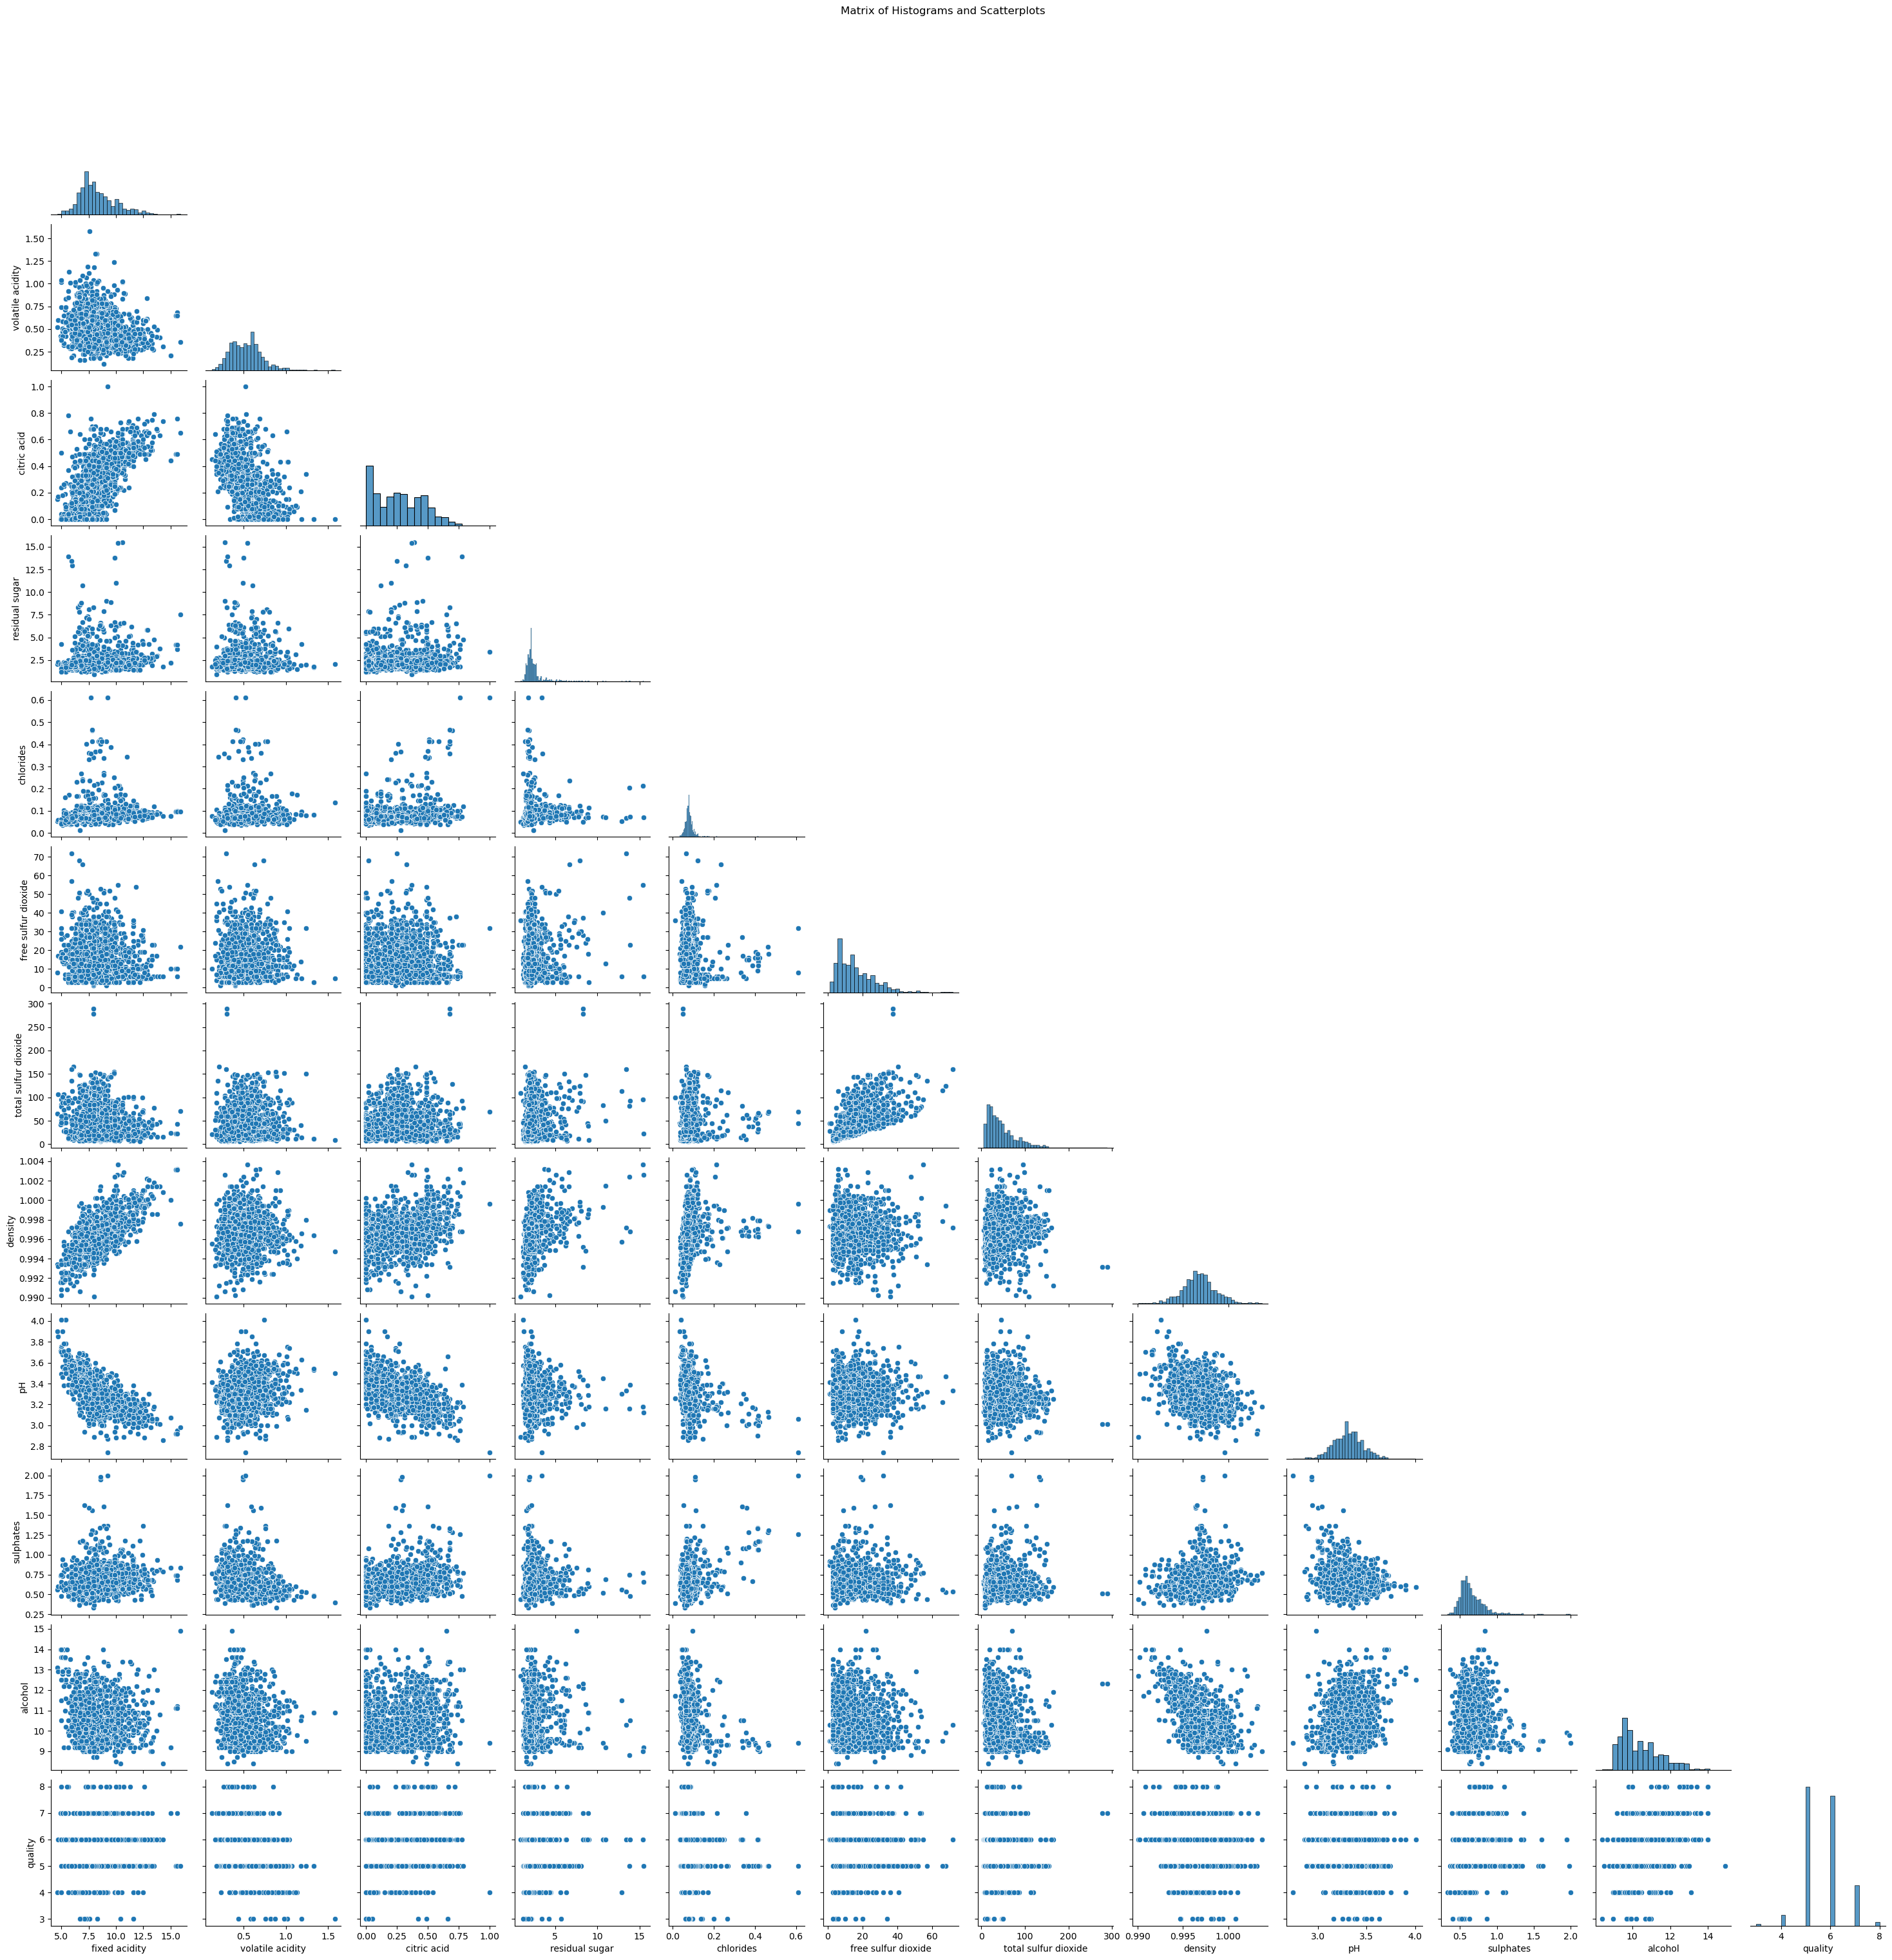

In [9]:
sns.pairplot(df, diag_kind='hist', corner=True,)
plt.suptitle("Matrix of Histograms and Scatterplots", y=1.02)
plt.show()


### check skewness and kurtosis of a dataset

**Skewness**: Measures asymmetry of the distribution.
- Positive skew → tail on the right
- Negative skew → tail on the left

**Kurtosis**: Measures tailedness or peakedness.
- High kurtosis → heavy tails (outliers)
- Low kurtosis → light tails (flat distribution)
- Normal distribution has kurtosis ≈ 3 (excess kurtosis ≈ 0)


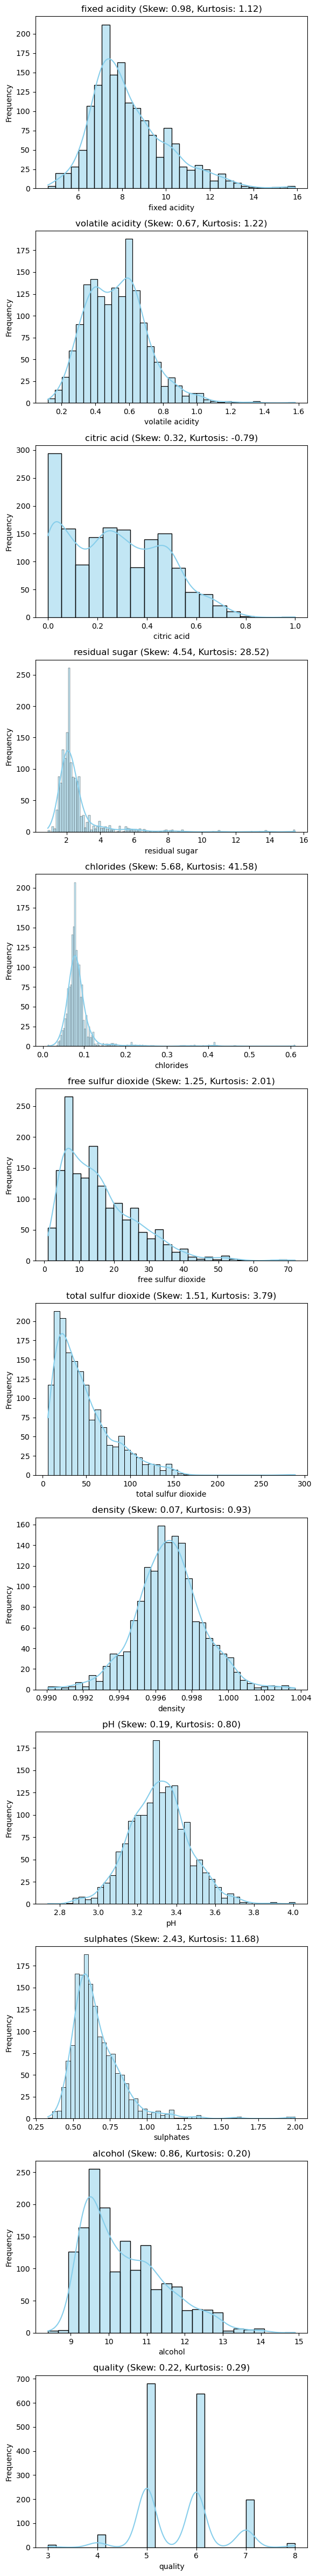

In [10]:
numeric_cols = df.select_dtypes(include='number').columns
# Set up subplots
n = len(numeric_cols.to_list())
fig, axes = plt.subplots(nrows=n, figsize=(6, 4 * n))
axes = axes.flatten()
# Plot each numeric column
for i, col in enumerate(numeric_cols.to_list()):
    ax = axes[i]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='skyblue')
    
    # Compute skewness and kurtosis
    sk = skew(df[col].dropna())
    ku = kurtosis(df[col].dropna())
    
    # Annotate
    ax.set_title(f"{col} (Skew: {sk:.2f}, Kurtosis: {ku:.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()



#### Outliesr detections

#### Interquartile Range Definition:

The interquartile range defines the difference between the third and the first quartile. Quartiles are the partitioned values that divide the ***whole series into 4 equal parts***. So, **there are 3 quartiles**. 
- First Quartile is denoted by **Q1** known as the lower quartile 
- The second Quartile is denoted by **Q2** 
- Third Quartile is denoted by **Q3** known as the upper quartile. 

- Q1 – Lower Quartile Part
- Q2 – Median
- Q3 – Upper Quartile Part

Therefore, the interquartile range is equal to the upper quartile minus lower quartile.

#### Interquartile Range Formula:

The difference between the upper and lower quartile is known as the interquartile range. The formula for the interquartile range is given below

***Interquartile range = Upper Quartile – Lower Quartile = Q­3 – Q­1***

where Q1 is the first quartile and Q3 is the third quartile of the series.



In [11]:
# Calculate IQR
numeric_cols = df.select_dtypes(include='number').columns

# Function to detect outliers
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

# Apply to each numeric column
outlier_summary = {}
for col in numeric_cols:
    outliers = detect_outliers_iqr(df[col])
    outlier_summary[col] = {
        'count': len(outliers),
        'indices': outliers.index.tolist()
    }

# Display summary
for col, info in outlier_summary.items():
    print(f"{col}: {info['count']} outliers → indices: {info['indices']}")


fixed acidity: 49 outliers → indices: [205, 206, 243, 244, 264, 294, 328, 338, 339, 347, 353, 359, 363, 364, 366, 374, 381, 391, 394, 409, 429, 440, 442, 446, 470, 472, 509, 510, 516, 538, 544, 548, 554, 555, 557, 559, 560, 564, 565, 596, 599, 601, 603, 611, 652, 680, 811, 814, 1224]
volatile acidity: 19 outliers → indices: [38, 94, 120, 126, 127, 134, 199, 553, 672, 690, 700, 705, 710, 724, 899, 1261, 1299, 1312, 1467]
citric acid: 1 outliers → indices: [151]
residual sugar: 155 outliers → indices: [9, 11, 14, 15, 18, 33, 35, 39, 40, 55, 57, 64, 65, 154, 155, 156, 157, 163, 164, 192, 215, 269, 270, 271, 272, 274, 275, 277, 278, 279, 283, 324, 325, 327, 353, 364, 366, 374, 375, 378, 395, 396, 400, 408, 409, 413, 415, 442, 455, 480, 484, 494, 501, 502, 510, 515, 516, 538, 539, 541, 554, 555, 556, 557, 558, 559, 564, 595, 606, 608, 624, 625, 645, 649, 652, 659, 690, 705, 719, 740, 800, 878, 884, 889, 903, 904, 910, 911, 913, 917, 923, 941, 944, 946, 974, 1032, 1038, 1043, 1056, 1057, 105

### Box Plot

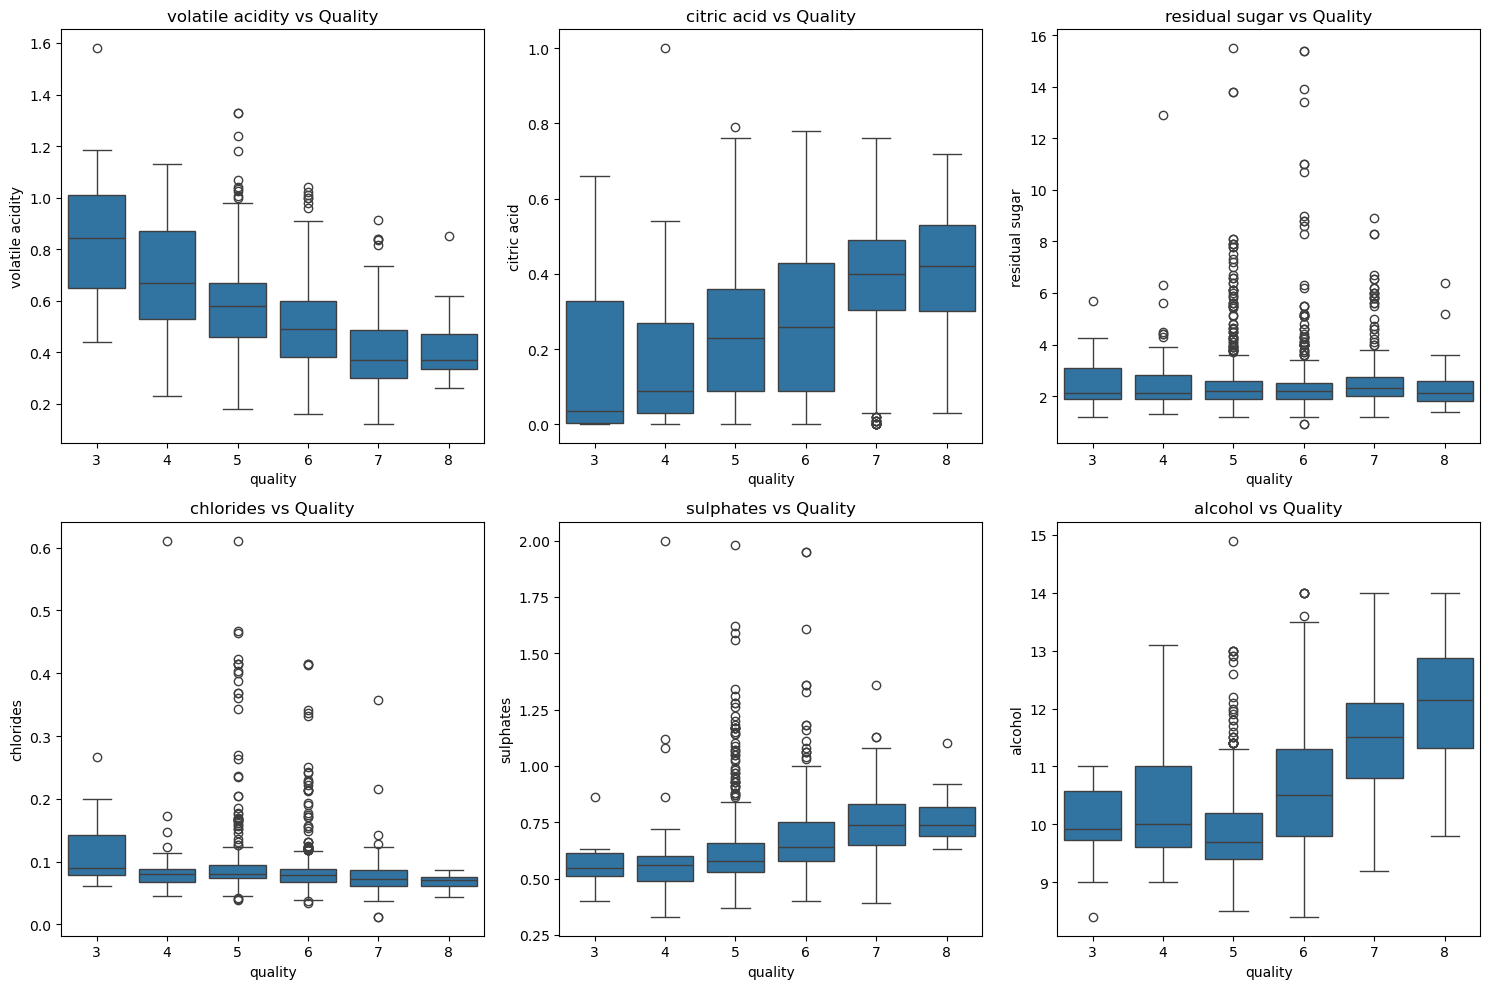

In [12]:
# Select key features
features = ['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'sulphates', 'alcohol']

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='quality', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'{feature} vs Quality')

plt.tight_layout()
plt.show()


#### Scatter plot

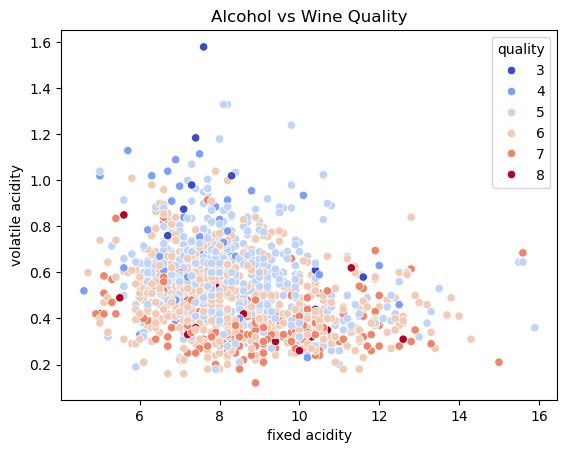

In [13]:

sns.scatterplot(data=df,x='fixed acidity',y='volatile acidity',hue='quality',palette='coolwarm')
plt.title('Alcohol vs Wine Quality')
plt.show()


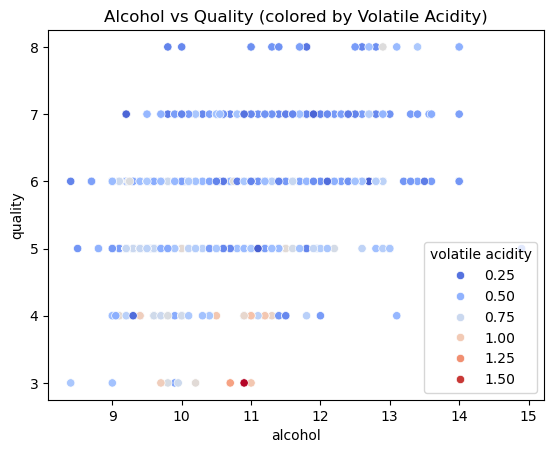

In [14]:
sns.scatterplot(x='alcohol', y='quality', hue='volatile acidity', data=df, palette='coolwarm')
plt.title('Alcohol vs Quality (colored by Volatile Acidity)')
plt.show()


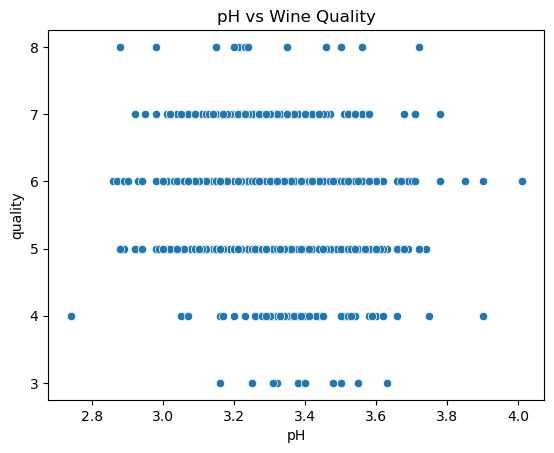

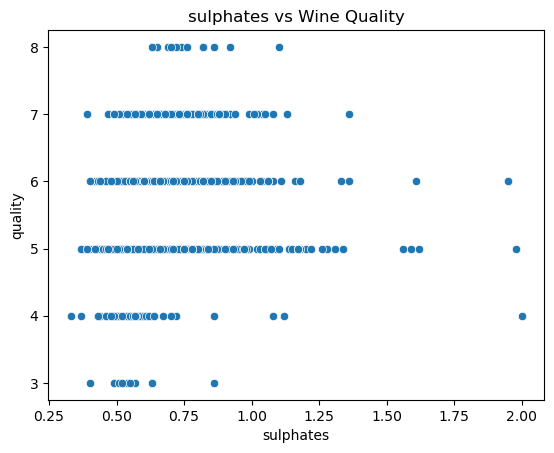

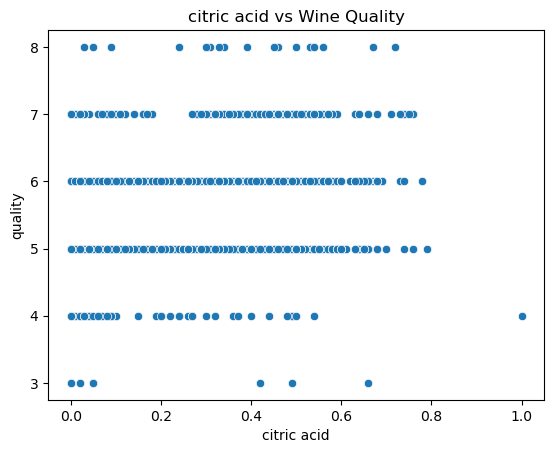

In [15]:
# Loop through multiple variables
features = ['pH', 'sulphates', 'citric acid']
for feature in features:
    sns.scatterplot(x=feature, y='quality', data=df)
    plt.title(f'{feature} vs Wine Quality')
    plt.show()


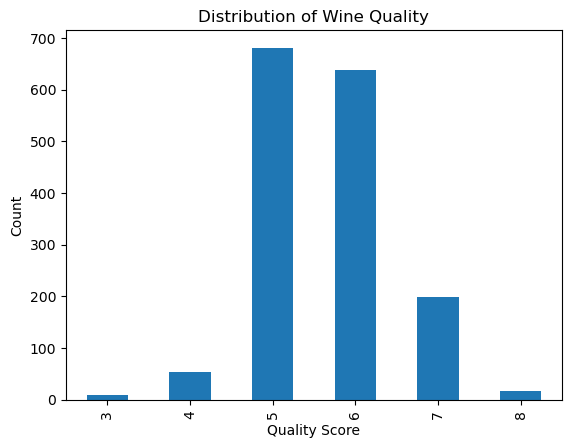

In [16]:
df['quality'].value_counts().sort_index().plot(kind='bar')

import matplotlib.pyplot as plt
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality')
plt.show()


#### Multicollinearity Test

In [18]:
import pandas as pd
import statsmodels.api as sm

path = os.path.join(os.getcwd(), 'winequality-red.csv')
df = pd.read_csv(path)

# Define predictors and response
X = df.drop(columns='quality')
y = df['quality']

# Add intercept
X = sm.add_constant(X)

# Fit GLM with Gaussian family (linear regression)
model = sm.GLM(y, X, family=sm.families.Gaussian())
result = model.fit()

# Summary
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                quality   No. Observations:                 1599
Model:                            GLM   Df Residuals:                     1587
Model Family:                Gaussian   Df Model:                           11
Link Function:               Identity   Scale:                         0.41992
Method:                          IRLS   Log-Likelihood:                -1569.1
Date:                Sat, 01 Nov 2025   Deviance:                       666.41
Time:                        10:42:11   Pearson chi2:                     666.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4286
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   21.9652 